# SIMULACIONES CLADDING AIRE

In [1]:
import matplotlib.pyplot as plt
import numpy as np

import tidy3d as td
import gplugins.tidy3d as gt
import gplugins.tidy3d.materials as mat
from gplugins import plot
from gplugins.common.config import PATH

from upvfab_design_tools import MMI_EME, DC_EME

nm = 1e-3
wavelength = np.linspace(1500, 1600) * nm
f = td.C_0 / wavelength
nitride_complex = td.material_library["Si3N4"]["Luke2015PMLStable"].eps_model(f)
nitride_index, nitride_k = td.Medium.eps_complex_to_nk(nitride_complex)

## MMI

2026-05-28 16:31:22.075 | INFO     | gplugins.tidy3d.modes:_data:266 - load data from .cache/Waveguide_fcbf6861dee3ecf0.npz.
Fracción TE: [0.99998437 0.99993597]


array([1.62897964+5.60394545e-05j, 1.62362391+5.63018095e-05j])

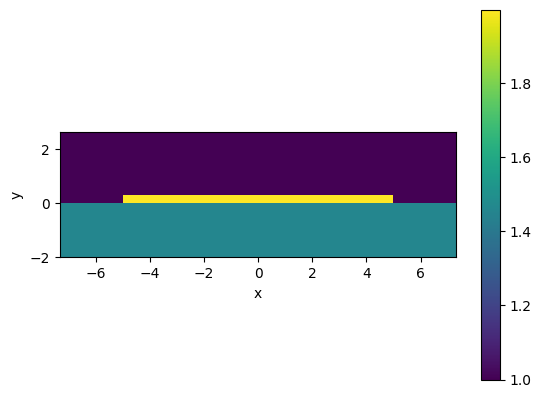

In [2]:
mmi_body_w = 10
lambda_c = 1.55

mmi_body_waveguide = gt.modes.Waveguide(
    # Geometrical Parameters
    core_width=mmi_body_w, # MMI Body width
    core_thickness=300 * nm, # MMI Body height 
    slab_thickness=0, # For shallow waveguides - Set to 0 if its a deep-etched waveguides.
    box_thickness = 2,
    # Materials
    core_material='sin', #  Material of the waveguide
    clad_material= 1, # Surrounding material
    box_material = 'sio2',
    # Modesolver Parameters
    wavelength=lambda_c, # Wavelength to simulate
    num_modes=2, # Targeted number of modes to find - Higher than before! It's a multimode section
    max_grid_scaling=1.45, # Parameters of the grid
    grid_resolution=40, # Parameters of the grid
    cache_path='.cache/', # Important! In order to save simulation time, set your cache Path!
    precision='double',
)

mmi_body_waveguide.plot_index()
pol = mmi_body_waveguide.fraction_te
print(f'Fracción TE: {pol}')
mmi_body_waveguide.n_eff

In [3]:
d_n_eff = mmi_body_waveguide.n_eff[0].real -  mmi_body_waveguide.n_eff[1].real

L_pi = 0.5*lambda_c/(d_n_eff)

print (L_pi)

144.70487546699283


## Guías

/home/maria_romero/TFG/.venv/lib/python3.12/site-packages/tidy3d/components/mode/derivatives.py:14: FutureWarning: Input has data type int64, but the output has been cast to float64.  In the future, the output data type will match the input. To avoid this warning, set the `dtype` parameter to `None` to have the output dtype match the input, or set it to the desired output data type.
  dxf = sp.csr_matrix(sp.diags([-1, 1], [0, 1], shape=(Nx, Nx)))
/home/maria_romero/TFG/.venv/lib/python3.12/site-packages/tidy3d/components/mode/derivatives.py:27: FutureWarning: Input has data type int64, but the output has been cast to float64.  In the future, the output data type will match the input. To avoid this warning, set the `dtype` parameter to `None` to have the output dtype match the input, or set it to the desired output data type.
  dxb = sp.csr_matrix(sp.diags([1, -1], [0, -1], shape=(Nx, Nx)))
/home/maria_romero/TFG/.venv/lib/python3.12/site-packages/tidy3d/components/mode/derivatives.py:4

16:34:21 CEST WARNING: Mode field at frequency index 0, mode index 1 does not   
              decay at the plane boundaries.                                    

              WARNING: The group index was not computed. To calculate group     
              index, pass 'group_index_step = True' in the 'ModeSpec'.          

2026-05-28 16:34:21.182 | INFO     | gplugins.tidy3d.modes:_data:306 - store data into .cache/Waveguide_da1cf71e66f20a65.npz.
Fracción TE: [0.98689431 0.00765815]


array([1.50057222+8.70784538e-05j, 1.44582677+2.08988504e-04j])

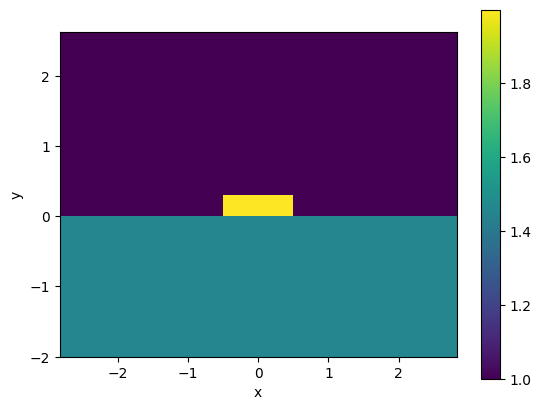

In [5]:
wg_width = 1
lambda_c = 1.55

waveguide = gt.modes.Waveguide(
    # Geometrical Parameters
    core_width=wg_width, # MMI Body width
    core_thickness=300 * nm, # MMI Body height 
    slab_thickness=0, # For shallow waveguides - Set to 0 if its a deep-etched waveguides.
    box_thickness = 2,
    # Materials
    core_material='sin', #  Material of the waveguide
    clad_material= 1, # Surrounding material
    box_material = 'sio2',
    # Modesolver Parameters
    wavelength=lambda_c, # Wavelength to simulate
    num_modes=2, # Targeted number of modes to find - Higher than before! It's a multimode section
    max_grid_scaling=1.45, # Parameters of the grid
    grid_resolution=40, # Parameters of the grid
    cache_path='.cache/', # Important! In order to save simulation time, set your cache Path!
    precision='double',
)

waveguide.plot_index()
pol = waveguide.fraction_te
print(f'Fracción TE: {pol}')
waveguide.n_eff

In [7]:
wl = np.linspace(1.5,1.6, 200)

waveguide = gt.modes.Waveguide(
    # Geometrical Parameters
    core_width=wg_width, # MMI Body width
    core_thickness=300 * nm, # MMI Body height 
    slab_thickness=0, # For shallow waveguides - Set to 0 if its a deep-etched waveguides.
    box_thickness = 2,
    # Materials
    core_material='sin', #  Material of the waveguide
    clad_material= 1, # Surrounding material
    box_material = 'sio2',
    # Modesolver Parameters
    wavelength=wl, # Wavelength to simulate
    num_modes=1, # Targeted number of modes to find - Higher than before! It's a multimode section
    max_grid_scaling=1.45, # Parameters of the grid
    grid_resolution=40, # Parameters of the grid
    cache_path='.cache/', # Important! In order to save simulation time, set your cache Path!
    precision='double',
)


neff = waveguide.n_eff.real




ng = neff - wl * np.gradient(neff, wl)

print(ng)

/home/maria_romero/TFG/.venv/lib/python3.12/site-packages/tidy3d/components/mode/derivatives.py:14: FutureWarning: Input has data type int64, but the output has been cast to float64.  In the future, the output data type will match the input. To avoid this warning, set the `dtype` parameter to `None` to have the output dtype match the input, or set it to the desired output data type.
  dxf = sp.csr_matrix(sp.diags([-1, 1], [0, 1], shape=(Nx, Nx)))
/home/maria_romero/TFG/.venv/lib/python3.12/site-packages/tidy3d/components/mode/derivatives.py:27: FutureWarning: Input has data type int64, but the output has been cast to float64.  In the future, the output data type will match the input. To avoid this warning, set the `dtype` parameter to `None` to have the output dtype match the input, or set it to the desired output data type.
  dxb = sp.csr_matrix(sp.diags([1, -1], [0, -1], shape=(Nx, Nx)))
/home/maria_romero/TFG/.venv/lib/python3.12/site-packages/tidy3d/components/mode/derivatives.py:4

2026-05-28 17:13:11.243 | INFO     | gplugins.tidy3d.modes:_data:306 - store data into .cache/Waveguide_abc6082f0c71900f.npz.
[2.00168649 2.00155504 2.00129193 2.0010284  2.00076444 2.00050005
 2.00023525 1.99997001 1.99970435 1.99943826 1.99917175 1.9989048
 1.99863743 1.99836963 1.99810141 1.99783275 1.99756366 1.99729414
 1.99702419 1.99675381 1.99647587 1.99620452 1.99593986 1.99566774
 1.99539519 1.99512221 1.99484879 1.99457494 1.99430065 1.99402592
 1.99375076 1.99347516 1.99319912 1.99292264 1.99264573 1.99236837
 1.99209058 1.99181234 1.99153367 1.99125455 1.99097499 1.99069499
 1.99041455 1.99013366 1.98985233 1.98957056 1.98928834 1.98900568
 1.98872257 1.98843902 1.98815502 1.98787057 1.98758568 1.98730034
 1.98701455 1.98672832 1.98644163 1.9861545  1.98586692 1.98557889
 1.9852904  1.98500147 1.98471208 1.98442225 1.98413196 1.98384122
 1.98355003 1.98325838 1.98296628 1.98267372 1.98238072 1.98208725
 1.98179334 1.98149896 1.98120413 1.98090885 1.98061311 1.98031691
 1.9

In [8]:
print(neff)

[1.52234795 1.52218737 1.52202688 1.52186647 1.52170615 1.52154592
 1.52138578 1.52122573 1.52106577 1.52090589 1.5207461  1.52058641
 1.5204268  1.52026728 1.52010785 1.51994851 1.51978926 1.5196301
 1.51947103 1.51931205 1.51915316 1.51899437 1.51883566 1.51867704
 1.51851851 1.51836007 1.51820172 1.51804347 1.5178853  1.51772723
 1.51756924 1.51741135 1.51725355 1.51709584 1.51693823 1.5167807
 1.51662327 1.51646593 1.51630868 1.51615152 1.51599445 1.51583748
 1.5156806  1.51552382 1.51536712 1.51521052 1.51505401 1.5148976
 1.51474128 1.51458505 1.51442891 1.51427287 1.51411693 1.51396107
 1.51380531 1.51364965 1.51349408 1.5133386  1.51318322 1.51302793
 1.51287274 1.51271764 1.51256264 1.51240773 1.51225292 1.5120982
 1.51194358 1.51178905 1.51163462 1.51148028 1.51132605 1.5111719
 1.51101785 1.5108639  1.51071005 1.51055629 1.51040263 1.51024906
 1.5100956  1.50994222 1.50978895 1.50963577 1.50948269 1.50932971
 1.50917683 1.50902404 1.50887135 1.50871876 1.50856626 1.50841387


In [9]:
# índice de grupo a wl=1.55
idx = np.argmin(abs(wl - 1.55))
ng_wl0 = ng[idx]
print(ng_wl0)

1.9736841993625058


In [10]:
# Cálculo de la diferencia de longitud de brazos necesaria para obtener un FSR de 10 pm con los datos simulados.
FSR = 1e-5 #um = 10pm
wl0 = 1.55

AL = (wl0**2)/(ng_wl0*FSR)

print(f'AL = {AL}')

AL = 121726.66735519293
